<a href="https://colab.research.google.com/github/steffiprog/Customer-Segmentation-ML-Project-HSE/blob/main/customer_segmentation_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Посмотреть какие файлы есть в датасете
files = kagglehub.dataset_download("jmmvutu/ecommerce-users-of-a-french-c2c-fashion-store")
print(files)

100%|██████████| 3.13M/3.13M [00:00<00:00, 138MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/jmmvutu/ecommerce-users-of-a-french-c2c-fashion-store/versions/6


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Загрузка данных
dataset_path = "/root/.cache/kagglehub/datasets/jmmvutu/ecommerce-users-of-a-french-c2c-fashion-store/versions/6"
file_path = os.path.join(dataset_path, 'users.6M0xxK.2024.public.csv')
df = pd.read_csv(file_path)

print("Данные загружены")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")
df.head()

# Типы данных и пропуски
df.info()

# Статистика
df.describe()

Данные загружены
Строк: 20743, Столбцов: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20743 entries, 0 to 20742
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   identifierHash       20743 non-null  int64  
 1   type                 20743 non-null  object 
 2   countryCode          20710 non-null  object 
 3   country              20743 non-null  object 
 4   language             20743 non-null  object 
 5   socialNbFollowers    20743 non-null  int64  
 6   socialNbFollows      20743 non-null  int64  
 7   socialProductsLiked  20743 non-null  int64  
 8   productsListed       20743 non-null  int64  
 9   productsSold         20743 non-null  int64  
 10  productsPassRate     20743 non-null  float64
 11  productsWished       20743 non-null  int64  
 12  productsBought       20743 non-null  int64  
 13  gender               20743 non-null  object 
 14  civilityGenderId     20743 non-null  int64

,identifierHash,socialNbFollowers,socialNbFollows,socialProductsLiked,productsListed,productsSold,productsPassRate,productsWished,productsBought,civilityGenderId,seniority,seniorityAsMonths,seniorityAsYears,websiteLongevity
count,2.074300e+04,20743.000000,20743.000000,20743.000000,20743.000000,20743.00000,20743.000000,20743.000000,20743.000000,20743.0,20743.000000,20743.000000,20743.00000,20743.0
mean,1.891011e+09,11.326231,15.645712,51.862363,0.622813,2.13431,8.487630,15.045172,2.722894,1.0,3066.299089,102.209844,8.51741,3803.0
std,1.281870e+09,56.131341,512.351535,573.693078,9.117789,15.50530,26.027697,130.633642,23.967183,0.0,168.012782,5.600623,0.46706,0.0
min,3.275870e+05,3.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.0,2853.000000,95.100000,7.92000,3803.0
25%,8.160869e+08,3.000000,8.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.0,2858.000000,95.270000,7.94000,3803.0
50%,1.620902e+09,3.000000,8.000000,2.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.0,3198.000000,106.600000,8.88000,3803.0
75%,2.975891e+09,7.000000,8.000000,16.000000,0.000000,0.00000,0.000000,2.000000,1.000000,1.0,3202.000000,106.730000,8.89000,3803.0
max,4.294836e+09,4134.000000,71045.000000,64267.000000,868.000000,843.00000,100.000000,6241.000000,2679.000000,1.0,3206.000000,106.870000,8.91000,3803.0


# Описание признаков датасета

## Идентификаторы и тип

| Колонка | Описание |
|---------|---------|
| `identifierHash` | Уникальный идентификатор пользователя (хэш) |
| `type` | Тип пользователя (все значения "user") |

---

## Поведенческие признаки

| Колонка | Описание | Для сегментации |
|---------|---------|-----------------|
| `productsListed` | Количество товаров, которые пользователь выставил на продажу | Определяет, является ли пользователь продавцом |
| `productsSold` | Количество проданных товаров | Активность продавца, успешность |
| `productsBought` | Количество купленных товаров | Активность покупателя |
| `productsWished` | Количество товаров, добавленных в желаемое | Интерес пользователя, потенциальные будущие покупки |
| `productsPassRate` | Процент успешных продаж (от 0 до 100) | Качество продавца |
| `socialProductsLiked` | Количество лайков, поставленных на товары | Вовлеченность пользователя |

---

## Социальные признаки

| Колонка | Описание | Для сегментации |
|---------|---------|-----------------|
| `socialNbFollowers` | Количество подписчиков пользователя | Популярность, влияние |
| `socialNbFollows` | На скольких пользователей подписан | Социальная активность |

---

## Демографические признаки

| Колонка | Описание | Для сегментации |
|---------|---------|-----------------|
| `gender` | Пол пользователя (M / F) | В данном датасете все значения "M" (мужчины) |
| `country` | Страна пользователя | Географическая сегментация |
| `countryCode` | Код страны (двухбуквенный) | Географическая сегментация |
| `language` | Язык интерфейса | Языковой сегмент |

---

## Признаки лояльности и доверия

| Колонка | Описание | Для сегментации |
|---------|---------|-----------------|
| `seniority` | Стаж на платформе в днях | Лояльность, "возраст" пользователя |
| `seniorityAsMonths` | Стаж на платформе в месяцах | Лояльность, "возраст" пользователя |
| `seniorityAsYears` | Стаж на платформе в годах | Лояльность, "возраст" пользователя |
| `hasProfilePicture` | Наличие фото профиля (True / False) | Доверие, заполненность профиля |

---

## Технические / бесполезные для сегментации

| Колонка | Описание | Почему не используем |
|---------|---------|---------------------|
| `civilityGenderId` | ID обращения (все значения 1) | Нет вариативности |
| `civilityTitle` | Текст обращения (все значения "mr") | Нет вариативности |
| `websiteLongevity` | Долголетие сайта (все 3803) | Нет вариативности |

---

## Итог: какие признаки использовать для сегментации

**Основные (поведение):**
- `productsBought` — покупательская активность
- `productsSold` — продавческая активность
- `productsWished` — интерес
- `socialProductsLiked` — вовлеченность

**Дополнительные (уточнение):**
- `country` — география
- `seniorityAsYears` — лояльность
- `hasProfilePicture` — доверие
- `socialNbFollowers` — популярность

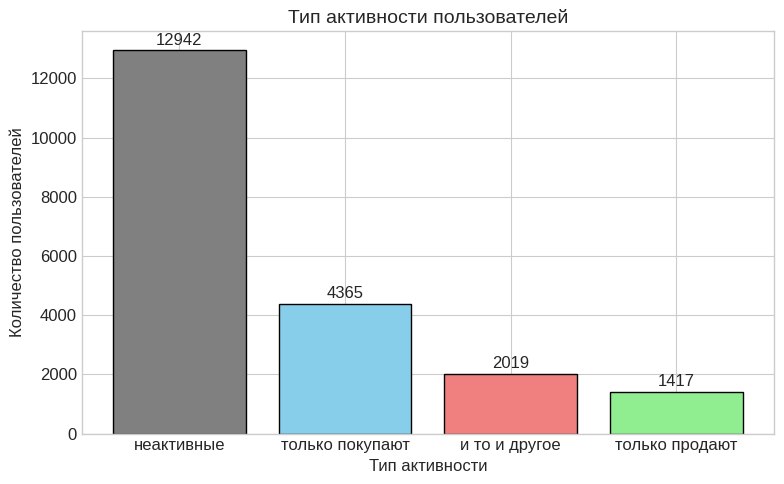


Статистика активности:
  Неактивные: 12942 человек
  Только покупают: 4365 человек
  Только продают: 1417 человек
  И то и другое: 2019 человек


In [ ]:
# Создаем категории активности
df['activity_type'] = 'неактивные'
df.loc[df['productsBought'] > 0, 'activity_type'] = 'только покупают'
df.loc[df['productsSold'] > 0, 'activity_type'] = 'только продают'
df.loc[(df['productsBought'] > 0) & (df['productsSold'] > 0), 'activity_type'] = 'и то и другое'

# Считаем количество
activity_counts = df['activity_type'].value_counts()

# Столбчатая диаграмма
plt.figure(figsize=(8, 5))
bars = plt.bar(activity_counts.index, activity_counts.values,
               color=['gray', 'skyblue', 'lightcoral', 'lightgreen'],
               edgecolor='black')
plt.title('Тип активности пользователей', fontsize=14)
plt.xlabel('Тип активности', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)

# Добавляем значения над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nСтатистика активности:")
print(f"  Неактивные: {activity_counts.get('неактивные', 0)} человек")
print(f"  Только покупают: {activity_counts.get('только покупают', 0)} человек")
print(f"  Только продают: {activity_counts.get('только продают', 0)} человек")
print(f"  И то и другое: {activity_counts.get('и то и другое', 0)} человек")

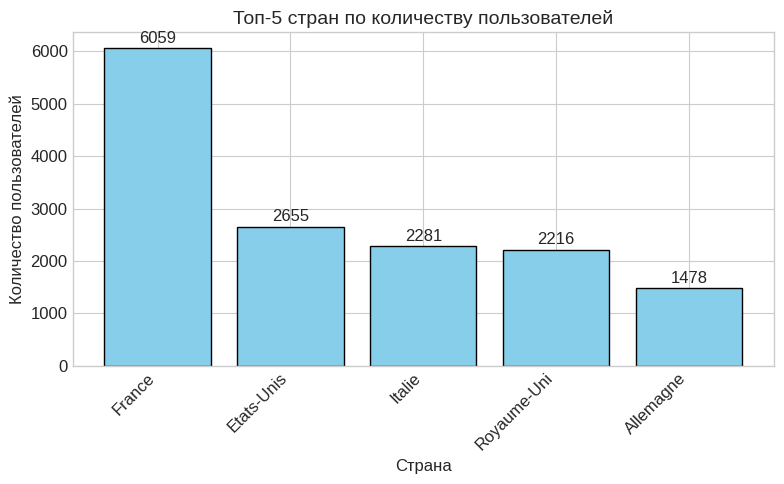


Топ-5 стран:
  France: 6059 пользователей
  Etats-Unis: 2655 пользователей
  Italie: 2281 пользователей
  Royaume-Uni: 2216 пользователей
  Allemagne: 1478 пользователей


In [ ]:
# Топ-5 стран
top_countries = df['country'].value_counts().head(5)

plt.figure(figsize=(8, 5))
bars = plt.bar(top_countries.index, top_countries.values,
               color='skyblue', edgecolor='black')
plt.title('Топ-5 стран по количеству пользователей', fontsize=14)
plt.xlabel('Страна', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Добавляем значения над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nТоп-5 стран:")
for country, count in top_countries.items():
    print(f"  {country}: {count} пользователей")

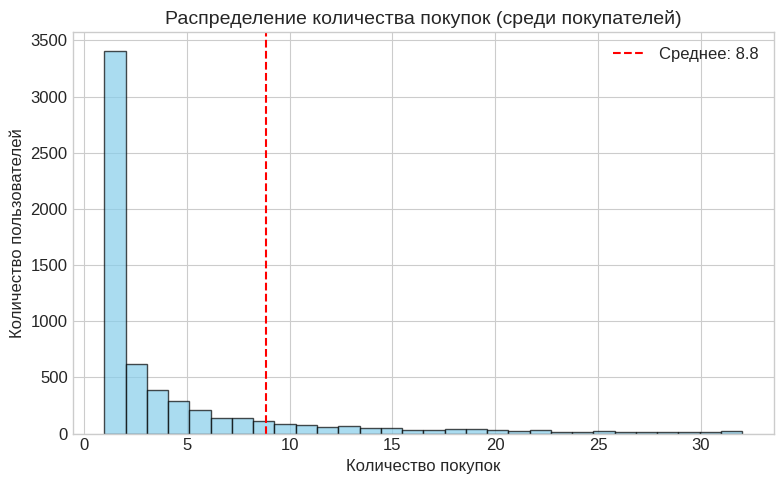


Статистика по покупкам:
  Всего покупателей: 6384 человек
  Среднее количество покупок: 8.85
  Медиана: 2
  Максимум: 2679


In [ ]:
# Берем только тех, кто покупал
buyers = df[df['productsBought'] > 0]

# Ограничиваем 95-м перцентилем для наглядности (убираем выбросы)
q95 = buyers['productsBought'].quantile(0.95)
buyers_filtered = buyers[buyers['productsBought'] <= q95]

plt.figure(figsize=(8, 5))
plt.hist(buyers_filtered['productsBought'], bins=30, edgecolor='black',
         alpha=0.7, color='skyblue')
plt.axvline(buyers['productsBought'].mean(), color='red', linestyle='--',
            label=f'Среднее: {buyers["productsBought"].mean():.1f}')
plt.title('Распределение количества покупок (среди покупателей)', fontsize=14)
plt.xlabel('Количество покупок', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nСтатистика по покупкам:")
print(f"  Всего покупателей: {len(buyers)} человек")
print(f"  Среднее количество покупок: {buyers['productsBought'].mean():.2f}")
print(f"  Медиана: {buyers['productsBought'].median():.0f}")
print(f"  Максимум: {buyers['productsBought'].max()}")

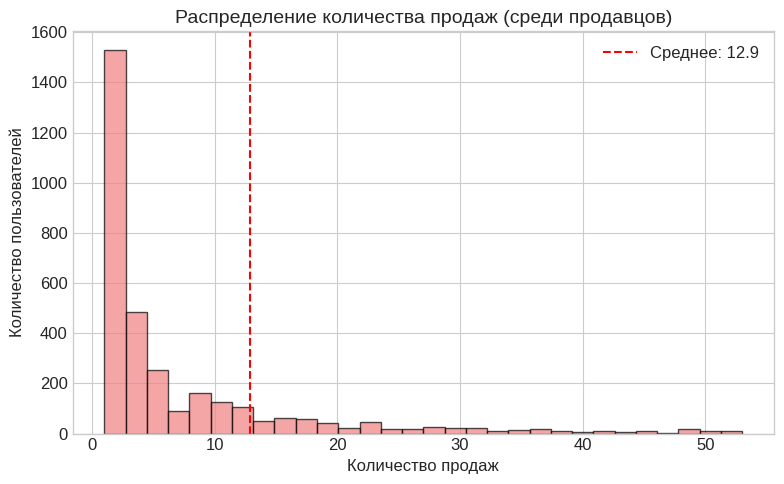


Статистика по продажам:
  Всего продавцов: 3436 человек
  Среднее количество продаж: 12.88
  Медиана: 3
  Максимум: 843


In [ ]:
# Берем только тех, кто продавал
sellers = df[df['productsSold'] > 0]

# Ограничиваем 95-м перцентилем для наглядности
q95 = sellers['productsSold'].quantile(0.95)
sellers_filtered = sellers[sellers['productsSold'] <= q95]

plt.figure(figsize=(8, 5))
plt.hist(sellers_filtered['productsSold'], bins=30, edgecolor='black',
         alpha=0.7, color='lightcoral')
plt.axvline(sellers['productsSold'].mean(), color='red', linestyle='--',
            label=f'Среднее: {sellers["productsSold"].mean():.1f}')
plt.title('Распределение количества продаж (среди продавцов)', fontsize=14)
plt.xlabel('Количество продаж', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nСтатистика по продажам:")
print(f"  Всего продавцов: {len(sellers)} человек")
print(f"  Среднее количество продаж: {sellers['productsSold'].mean():.2f}")
print(f"  Медиана: {sellers['productsSold'].median():.0f}")
print(f"  Максимум: {sellers['productsSold'].max()}")

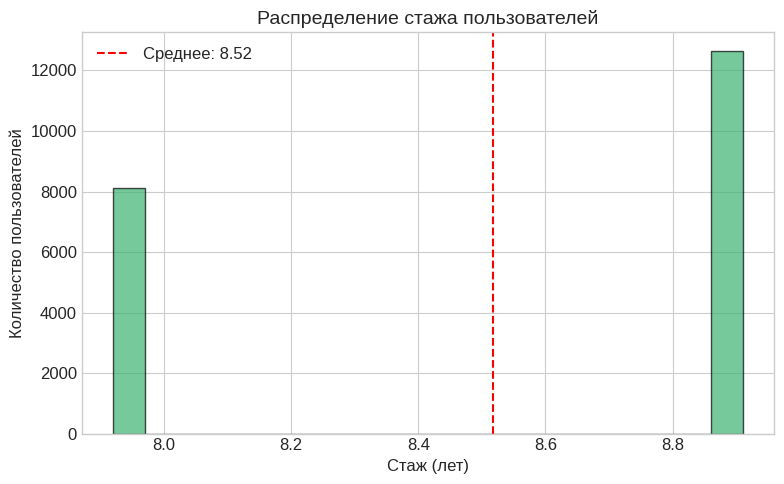


Статистика по стажу:
  Средний стаж: 8.52 лет
  Минимальный стаж: 7.92 лет
  Максимальный стаж: 8.91 лет


In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['seniorityAsYears'], bins=20, edgecolor='black',
         alpha=0.7, color='mediumseagreen')
plt.axvline(df['seniorityAsYears'].mean(), color='red', linestyle='--',
            label=f'Среднее: {df["seniorityAsYears"].mean():.2f}')
plt.title('Распределение стажа пользователей', fontsize=14)
plt.xlabel('Стаж (лет)', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nСтатистика по стажу:")
print(f"  Средний стаж: {df['seniorityAsYears'].mean():.2f} лет")
print(f"  Минимальный стаж: {df['seniorityAsYears'].min():.2f} лет")
print(f"  Максимальный стаж: {df['seniorityAsYears'].max():.2f} лет")

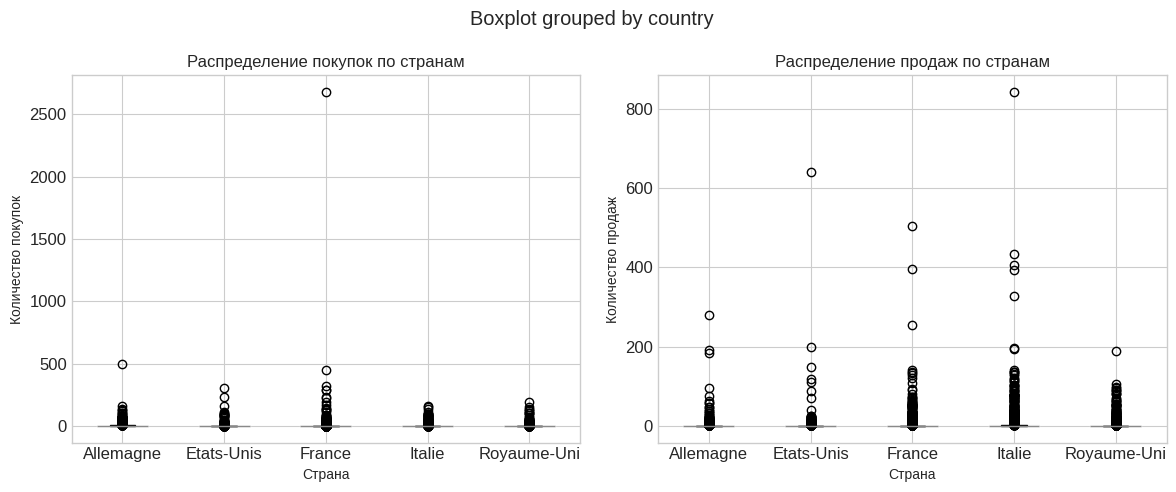

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot покупок по странам (топ-5)
ax1 = axes[0]
top5_countries = df['country'].value_counts().head(5).index
df_top5 = df[df['country'].isin(top5_countries)]
df_top5.boxplot(column='productsBought', by='country', ax=ax1)
ax1.set_title('Распределение покупок по странам', fontsize=12)
ax1.set_xlabel('Страна', fontsize=10)
ax1.set_ylabel('Количество покупок', fontsize=10)

# Box plot продаж по странам (топ-5)
ax2 = axes[1]
df_top5.boxplot(column='productsSold', by='country', ax=ax2)
ax2.set_title('Распределение продаж по странам', fontsize=12)
ax2.set_xlabel('Страна', fontsize=10)
ax2.set_ylabel('Количество продаж', fontsize=10)

plt.tight_layout()
plt.show()

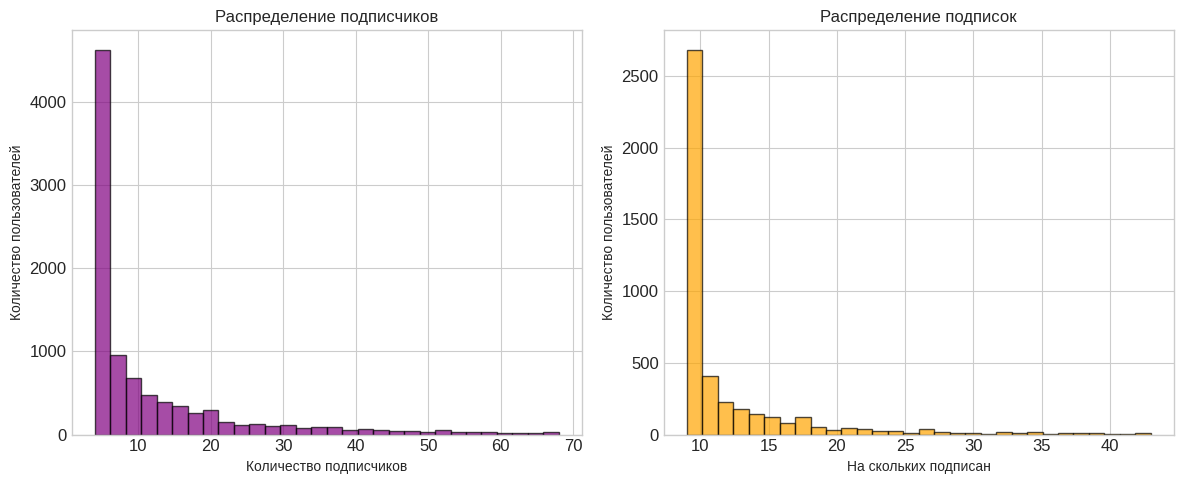


Статистика по подписчикам:
  Среднее: 11.3
  Медиана: 3
  Максимум: 4134

Статистика по подпискам:
  Среднее: 15.6
  Медиана: 8
  Максимум: 71045


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Социальные подписчики (только те, у кого >0)
followers = df[df['socialNbFollowers'] > 3]  # убираем базовое значение 3
followers_filtered = followers[followers['socialNbFollowers'] <= followers['socialNbFollowers'].quantile(0.95)]

ax1 = axes[0]
ax1.hist(followers_filtered['socialNbFollowers'], bins=30, edgecolor='black', alpha=0.7, color='purple')
ax1.set_title('Распределение подписчиков', fontsize=12)
ax1.set_xlabel('Количество подписчиков', fontsize=10)
ax1.set_ylabel('Количество пользователей', fontsize=10)

# Социальные подписки
follows = df[df['socialNbFollows'] > 8]  # убираем базовое значение 8
follows_filtered = follows[follows['socialNbFollows'] <= follows['socialNbFollows'].quantile(0.95)]

ax2 = axes[1]
ax2.hist(follows_filtered['socialNbFollows'], bins=30, edgecolor='black', alpha=0.7, color='orange')
ax2.set_title('Распределение подписок', fontsize=12)
ax2.set_xlabel('На скольких подписан', fontsize=10)
ax2.set_ylabel('Количество пользователей', fontsize=10)

plt.tight_layout()
plt.show()

print("\nСтатистика по подписчикам:")
print(f"  Среднее: {df['socialNbFollowers'].mean():.1f}")
print(f"  Медиана: {df['socialNbFollowers'].median():.0f}")
print(f"  Максимум: {df['socialNbFollowers'].max()}")
print(f"\nСтатистика по подпискам:")
print(f"  Среднее: {df['socialNbFollows'].mean():.1f}")
print(f"  Медиана: {df['socialNbFollows'].median():.0f}")
print(f"  Максимум: {df['socialNbFollows'].max()}")

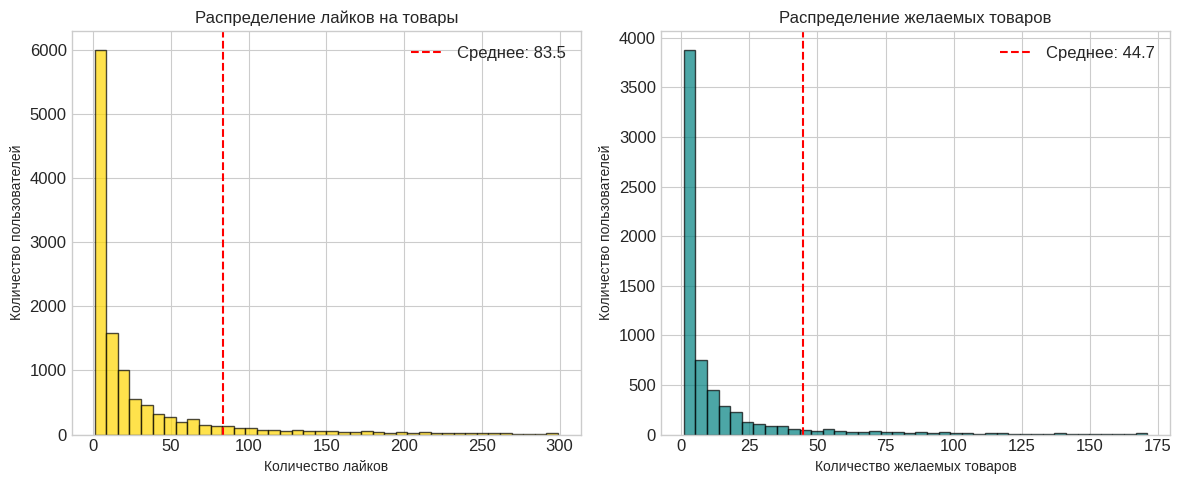


Статистика по лайкам:
  Пользователи с лайками: 12888 человек (62.1%)
  Среднее количество лайков: 83.5

Статистика по желаемым товарам:
  Пользователи с желаемым: 6974 человек (33.6%)
  Среднее количество желаемых товаров: 44.7


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Лайки на товары
likes = df[df['socialProductsLiked'] > 0]
likes_filtered = likes[likes['socialProductsLiked'] <= likes['socialProductsLiked'].quantile(0.95)]

ax1 = axes[0]
ax1.hist(likes_filtered['socialProductsLiked'], bins=40, edgecolor='black', alpha=0.7, color='gold')
ax1.set_title('Распределение лайков на товары', fontsize=12)
ax1.set_xlabel('Количество лайков', fontsize=10)
ax1.set_ylabel('Количество пользователей', fontsize=10)
ax1.axvline(likes['socialProductsLiked'].mean(), color='red', linestyle='--',
            label=f'Среднее: {likes["socialProductsLiked"].mean():.1f}')
ax1.legend()

# Желаемые товары
wished = df[df['productsWished'] > 0]
wished_filtered = wished[wished['productsWished'] <= wished['productsWished'].quantile(0.95)]

ax2 = axes[1]
ax2.hist(wished_filtered['productsWished'], bins=40, edgecolor='black', alpha=0.7, color='teal')
ax2.set_title('Распределение желаемых товаров', fontsize=12)
ax2.set_xlabel('Количество желаемых товаров', fontsize=10)
ax2.set_ylabel('Количество пользователей', fontsize=10)
ax2.axvline(wished['productsWished'].mean(), color='red', linestyle='--',
            label=f'Среднее: {wished["productsWished"].mean():.1f}')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nСтатистика по лайкам:")
print(f"  Пользователи с лайками: {len(likes)} человек ({len(likes)/len(df)*100:.1f}%)")
print(f"  Среднее количество лайков: {likes['socialProductsLiked'].mean():.1f}")
print(f"\nСтатистика по желаемым товарам:")
print(f"  Пользователи с желаемым: {len(wished)} человек ({len(wished)/len(df)*100:.1f}%)")
print(f"  Среднее количество желаемых товаров: {wished['productsWished'].mean():.1f}")

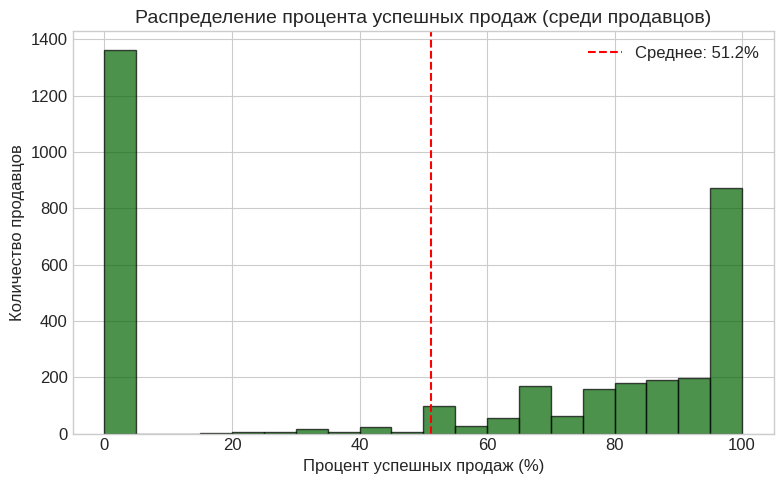


Статистика по успешности продаж:
  Средний процент успешных продаж: 51.2%
  Медиана: 66%
  Есть продавцы с 100% успешностью: 779 человек


In [ ]:
# Только те, у кого есть продажи
sellers = df[df['productsSold'] > 0]

plt.figure(figsize=(8, 5))
plt.hist(sellers['productsPassRate'], bins=20, edgecolor='black', alpha=0.7, color='darkgreen')
plt.title('Распределение процента успешных продаж (среди продавцов)', fontsize=14)
plt.xlabel('Процент успешных продаж (%)', fontsize=12)
plt.ylabel('Количество продавцов', fontsize=12)
plt.axvline(sellers['productsPassRate'].mean(), color='red', linestyle='--',
            label=f'Среднее: {sellers["productsPassRate"].mean():.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

print("\nСтатистика по успешности продаж:")
print(f"  Средний процент успешных продаж: {sellers['productsPassRate'].mean():.1f}%")
print(f"  Медиана: {sellers['productsPassRate'].median():.0f}%")
print(f"  Есть продавцы с 100% успешностью: {len(sellers[sellers['productsPassRate'] == 100])} человек")

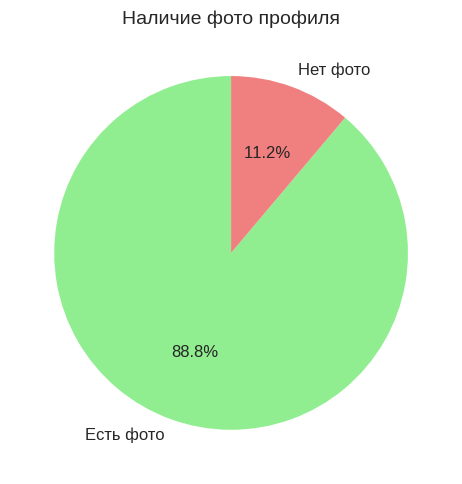


Пользователи с фото профиля: 18430 человек (88.8%)
Пользователи без фото: 2313 человек (11.2%)


In [ ]:
plt.figure(figsize=(6, 5))
photo_counts = df['hasProfilePicture'].value_counts()
labels = ['Есть фото', 'Нет фото']
colors = ['lightgreen', 'lightcoral']

plt.pie(photo_counts.values, labels=labels, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Наличие фото профиля', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nПользователи с фото профиля: {photo_counts.get(True, 0)} человек ({photo_counts.get(True, 0)/len(df)*100:.1f}%)")
print(f"Пользователи без фото: {photo_counts.get(False, 0)} человек ({photo_counts.get(False, 0)/len(df)*100:.1f}%)")

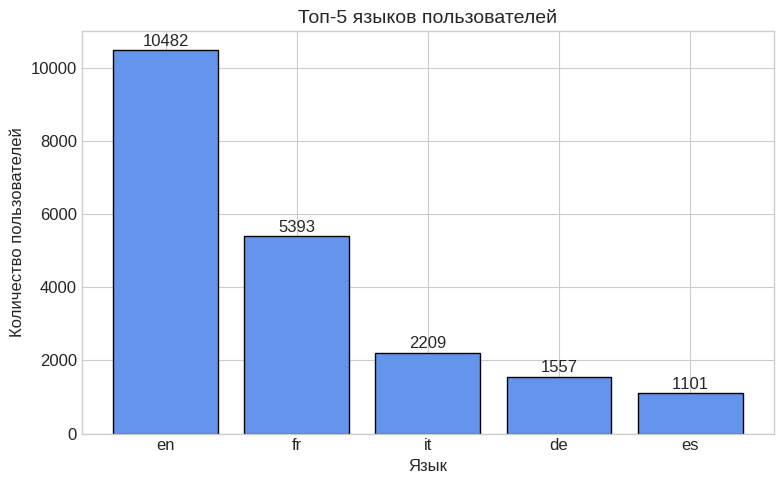


Топ-5 языков:
  en: 10482 пользователей
  fr: 5393 пользователей
  it: 2209 пользователей
  de: 1557 пользователей
  es: 1101 пользователей


In [ ]:
# Топ-5 языков
top_languages = df['language'].value_counts().head(5)

plt.figure(figsize=(8, 5))
bars = plt.bar(top_languages.index, top_languages.values,
               color='cornflowerblue', edgecolor='black')
plt.title('Топ-5 языков пользователей', fontsize=14)
plt.xlabel('Язык', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nТоп-5 языков:")
for lang, count in top_languages.items():
    print(f"  {lang}: {count} пользователей")

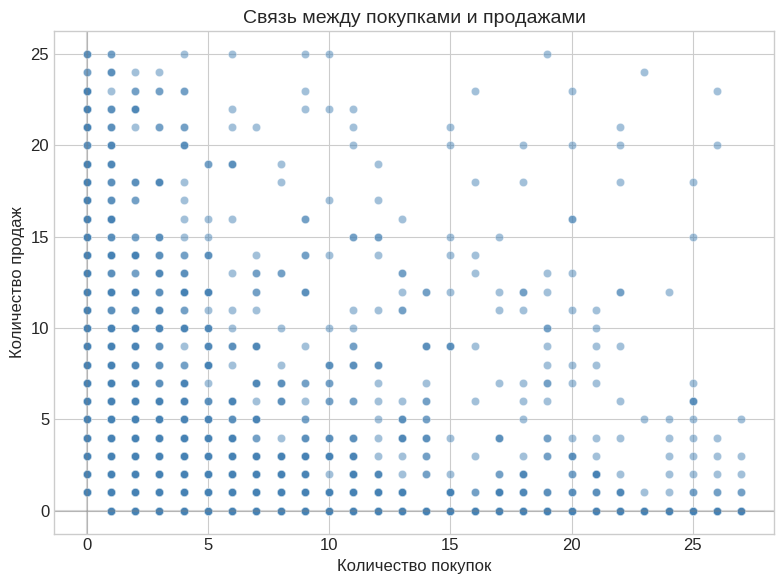


Интерпретация:
  Большинство пользователей находятся в левом верхнем углу
  (покупают, но не продают)
  Чем правее точка, тем больше покупок
  Чем выше точка, тем больше продаж


In [ ]:
# Сравнение покупок и продаж (только активные пользователи)
active = df[(df['productsBought'] > 0) | (df['productsSold'] > 0)]

# Ограничиваем для наглядности
active_filtered = active[
    (active['productsBought'] <= active['productsBought'].quantile(0.95)) &
    (active['productsSold'] <= active['productsSold'].quantile(0.95))
]

plt.figure(figsize=(8, 6))
plt.scatter(active_filtered['productsBought'], active_filtered['productsSold'],
            alpha=0.5, c='steelblue', edgecolors='white', linewidth=0.5)
plt.xlabel('Количество покупок', fontsize=12)
plt.ylabel('Количество продаж', fontsize=12)
plt.title('Связь между покупками и продажами', fontsize=14)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nИнтерпретация:")
print("  Большинство пользователей находятся в левом верхнем углу")
print("  (покупают, но не продают)")
print("  Чем правее точка, тем больше покупок")
print("  Чем выше точка, тем больше продаж")

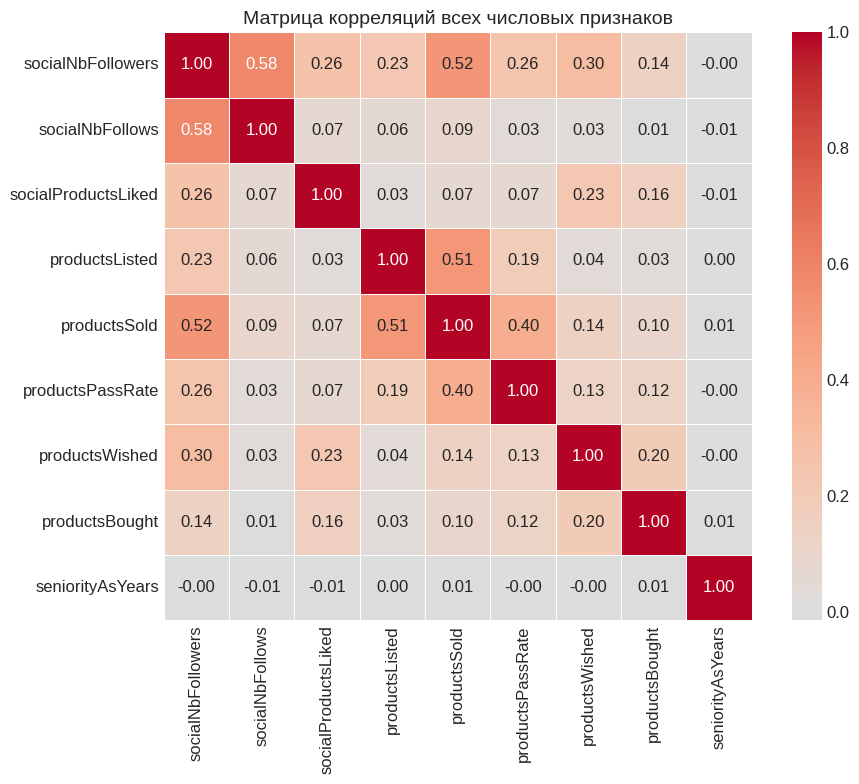


Сильные корреляции (|r| > 0.5):
  socialNbFollowers <-> socialNbFollows: 0.58
  socialNbFollowers <-> productsSold: 0.52
  productsListed <-> productsSold: 0.51


In [ ]:
# Все числовые признаки
numeric_cols = ['socialNbFollowers', 'socialNbFollows', 'socialProductsLiked',
                'productsListed', 'productsSold', 'productsPassRate',
                'productsWished', 'productsBought', 'seniorityAsYears']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Матрица корреляций всех числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

print("\nСильные корреляции (|r| > 0.5):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.5:
            print(f"  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr:.2f}")